
#Q2. Label Construction & Dataset Preparation 



In [2]:
pip install rasterio #To read and work with raster data (.tif)


   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/25.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/25.7 MB 3.0 MB/s eta 0:00:09
   - -------------------------------------- 1.0/25.7 MB 2.5 MB/s eta 0:00:10
   - -------------------------------------- 1.0/25.7 MB 2.5 MB/s eta 0:00:10
   -- ------------------------------------- 1.6/25.7 MB 1.6 MB/s eta 0:00:15
   --- ------------------------------------ 2.1/25.7 MB 1.8 MB/s eta 0:00:13
   --- ------------------------------------ 2.4/25.7 MB 1.7 MB/s eta 0:00:15
   ---- ----------------------------------- 2.9/25.7 MB 1.8 MB/s eta 0:00:13
   ----- ---------------------------------- 3.4/25.7 MB 1.8 MB/s eta 0:00:13
   ------ --------------------------------- 3.9/25.7 MB 2.0 MB/s eta 0:00:12
   ------ --------------------------------- 4.2/25.7 MB 2.0 MB/s eta 0:00:11
   ------ --------------------------------- 4.2/25.7 MB 2.0 MB/s eta 0:00:11
   ------ --

In [2]:
#i) For each image, extract the  128×128 corresponding land-cover patch from land_cover.tif using its center coordinate (2 marks)


import rasterio
from rasterio.windows import Window
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#load ladcover dataset the tif file
landcover_path = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\raster\landcover\land_cover.tif"
lc_dataset = rasterio.open(landcover_path)

# loading the filtered images file to classifiy according to esa code, here both the tif file and our csv file will be in use
filtered_images = pd.read_csv(
    r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\processed\filtered_image\filtered_image_centers.csv"
)

#iii) Map ESA class codes to simplified land-use categories (e.g., Built-up, Vegetation, Water, Cropland, Others). (1 mark) 
# we are first assignging class code then will assign dominant class, since before assigning dominant class 
esa_to_simple = {
    50: "Built-up",
    40: "Cropland",
    80: "Water",
    10: "Vegetation",
    20: "Vegetation",
    30: "Vegetation",
    60: "Others",
    90: "Others",
    95: "Others",
    100: "Others"
}

#final dataset will be stored 
image_names = []
labels = []

half_size = 64  # 128 / 2  because buffer of 64 on all side will give us the centered window

#loop all over the image
for _, row in filtered_images.iterrows():

    #extract lat/lon from filename
    name = row["image_name"].replace(".png", "")
    lat_str, lon_str = name.split("_")
    lat = float(lat_str)
    lon = float(lon_str)

    #check if point lies inside raster extent
    if not (
        lc_dataset.bounds.left <= lon <= lc_dataset.bounds.right and
        lc_dataset.bounds.bottom <= lat <= lc_dataset.bounds.top
    ):
        continue

    #  convert to raster indices 
    row_idx, col_idx = lc_dataset.index(lon, lat)

    # ensure full 128×128 window fits
    if (row_idx - half_size < 0 or
        col_idx - half_size < 0 or
        row_idx + half_size >= lc_dataset.height or
        col_idx + half_size >= lc_dataset.width):
        continue

    #extract land-cover patch
    window = Window(col_idx - half_size, row_idx - half_size, 128, 128)
    patch = lc_dataset.read(1, window=window)

    # Assign the image label using the dominant (mode) land-cover class. (1 mark)
    pixels = patch.flatten()
    classes, counts = np.unique(pixels, return_counts=True)
    dominant_class = classes[np.argmax(counts)]

    # map to simplified label (iii) 
    final_label = esa_to_simple.get(dominant_class, "Others")

    # store result
    image_names.append(row["image_name"])
    labels.append(final_label)

# Create final labeled dataset for training

dataset_df = pd.DataFrame({
    "image_name": image_names,
    "label": labels
})

print("\nTotal labeled images:", len(dataset_df))
print(dataset_df.head())




Total labeled images: 8015
            image_name     label
0  28.2056_76.8558.png  Built-up
1  28.2056_76.8646.png  Built-up
2  28.2056_76.8734.png  Built-up
3  28.2056_76.8822.png  Built-up
4  28.2056_76.8910.png  Cropland



Training samples: 4809
Testing samples: 3206


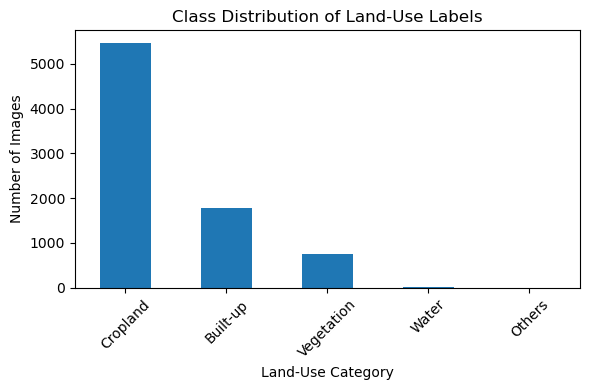

In [6]:

# iv) 60/40 Train–Test Split
train_df, test_df = train_test_split(
    dataset_df,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

print("\nTraining samples:", len(train_df))
print("Testing samples:", len(test_df))

# iv): Visualize class distribution
class_counts = dataset_df["label"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.xlabel("Land-Use Category")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Land-Use Labels")
plt.xticks(rotation=45)
plt.tight_layout()
output_path = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations\class_distribution_land_use_labels.png"
plt.savefig(output_path, dpi=300)
plt.show()


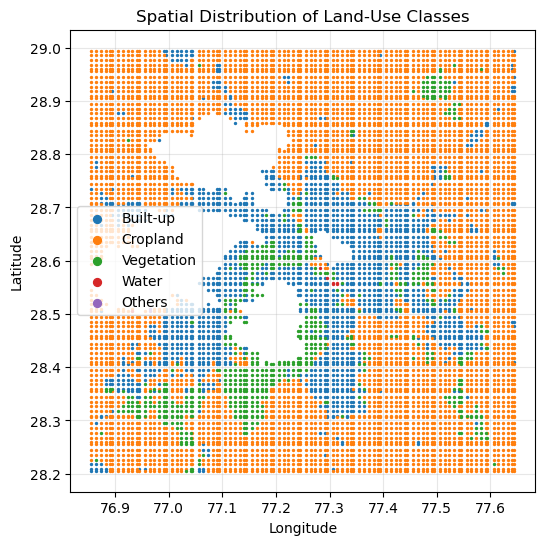

In [5]:
# Extract lat/lon again for plotting
dataset_df["lat"] = dataset_df["image_name"].apply(lambda x: float(x.split("_")[0]))
dataset_df["lon"] = dataset_df["image_name"].apply(lambda x: float(x.split("_")[1].replace(".png","")))

plt.figure(figsize=(6, 6))

for label in dataset_df["label"].unique():
    subset = dataset_df[dataset_df["label"] == label]
    plt.scatter(subset["lon"], subset["lat"], s=2, label=label)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Land-Use Classes")
plt.legend(markerscale=4)
plt.grid(alpha=0.3)
spatial_path = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations\spatial_distribution.png"
plt.savefig(spatial_path, dpi=300)
plt.show()

In [16]:
# to be used for ques 3 
dataset_df.to_csv(
    r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\processed\labeled_dataset.csv",
    index=False
)